In [7]:
import pandas as pd
import numpy as np

scores_and_sections = pd.read_csv("scores_by_section-1.csv")
score_col = scores_and_sections.columns[1]

p85 = np.percentile(scores_and_sections[score_col], 85)
p85

22.0

In [8]:
# read CSV and keep/reindex to the requested columns
_df = pd.read_csv("san_francisco_2019-1.csv")
cols = ['Organization Group', 'Department', 'Job Family', 'Job', 'Salary', 'Overtime', 'Benefits', 'Total Compensation']
employees_sf = _df.reindex(columns=cols)
employees_sf.head()

,Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
0,Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332.0,0.0,40059.0,131391.0
1,Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241.0,0.0,49279.0,172520.0
2,Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715.0,0.0,46752.0,162468.0
3,Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394.0,0.0,57312.0,216706.0
4,Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035.0,0.0,28671.0,98706.0


In [9]:
total_employees = len(employees_sf)
high_earners = len(employees_sf[employees_sf['Total Compensation'] > 15000])

print(f"Total employees: {total_employees}")
print(f"Employees with Total Compensation > 15000: {high_earners}")

Total employees: 44525
Employees with Total Compensation > 15000: 37762


<Axes: ylabel='Frequency'>

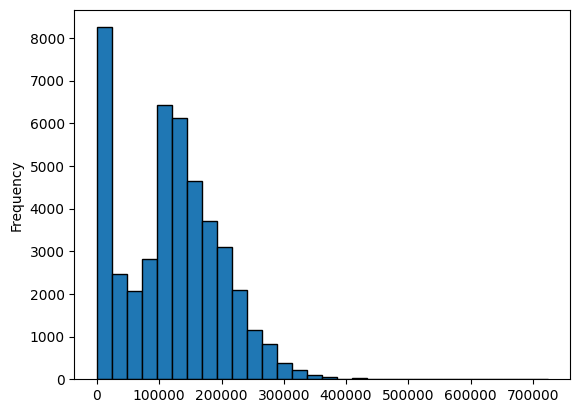

In [10]:
employees_sf['Total Compensation'].plot.hist(bins=30, edgecolor='black')

In [11]:
np.percentile(employees_sf['Total Compensation'], 50)

121630.0

In [12]:
def one_bootstrap_median():
    bs = employees_sf['Total Compensation'].sample(frac=1, replace=True)
    return bs.median()

one_bootstrap_median()

121393.0

121654.0

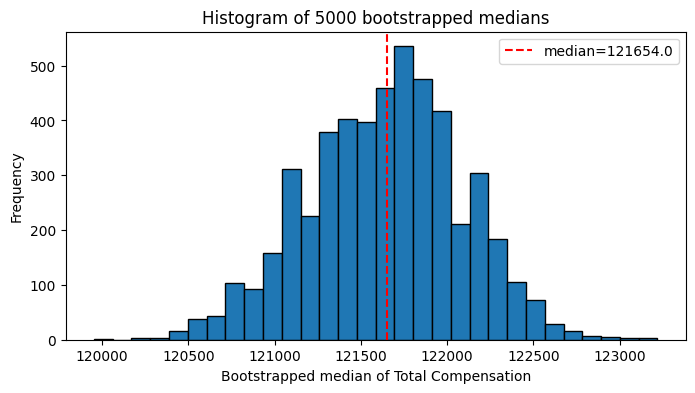

In [13]:
import matplotlib.pyplot as plt

n_boot = 5000
bs_medians = [one_bootstrap_median() for _ in range(n_boot)]

plt.figure(figsize=(8,4))
plt.hist(bs_medians, bins=30, edgecolor='black')
plt.axvline(np.median(bs_medians), color='red', linestyle='--', label=f"median={np.median(bs_medians):.1f}")
plt.legend()
plt.xlabel('Bootstrapped median of Total Compensation')
plt.ylabel('Frequency')
plt.title('Histogram of 5000 bootstrapped medians')

np.median(bs_medians)

In [19]:
lower_bound = np.percentile(bs_medians, 97.5)
lower_bound

122470.0

In [20]:
numbers_string = "30 26 33 26 26 33 31 31 21 37 27 20 34 35 30 24 38 34 39 31 22 30 23 23 31 44 31 33 33 26 27 28 25 35 23 32 29 31 25 27"
numbers = [float(x) for x in numbers_string.split()]
mean = sum(numbers) / len(numbers)
mean

29.6


In [23]:
sample = np.array([float(x) for x in numbers_string.split()])

n = len(sample)
sample_std = sample.std()  # sample standard deviation
margin_of_error_95 = 1.96 * sample_std / np.sqrt(n)

margin_of_error_95

1.614473784240549

In [26]:
# Hardcoded values
critical_value = 1.796
ME = 41.049035
s1 = 66.6012
s2 = 47.86618
df = 11

# Find SE using critical value and margin of error
SE = ME / critical_value
print(f"Standard Error (SE): {SE}")

# Assume mean1 and mean2 are already defined in the notebook
diff_means = mean1 - mean2
print(f"Difference in means: {diff_means}")

# Standardized test statistic (t)
t_stat_manual = diff_means / SE
print(f"Standardized test statistic (t): {t_stat_manual}")

# Calculate p-value manually (two-tailed)
# For two-tailed, p = 2 * P(T > |t|) where T ~ t_{df}
# We'll use the cumulative distribution function (CDF) from scipy.stats, but show the manual calculation
from scipy.stats import t as t_dist
p_value_manual = 2 * (1 - t_dist.cdf(abs(t_stat_manual), df))
print(f"p-value: {p_value_manual}")

Standard Error (SE): 22.855810133630293
Difference in means: -38.38333333333321
Standardized test statistic (t): -1.6793687517055258
p-value: 0.12122666826351547


In [30]:
measured = np.array([152.6, 149.3, 174.8, 119.5, 194.9, 180.3, 215.4, 239.6])
reported = np.array([150.0, 148.0, 170.0, 119.0, 185.0, 180.0, 224.0, 239.0])

d = measured - reported
n = len(d)
df = n - 1
alpha = 0.10

mean_d = d.mean()
std_d = d.std(ddof=1)
t_crit = t_dist.ppf(1 - alpha / 2, df)
E = t_crit * std_d / np.sqrt(n)

left = mean_d - E
right = mean_d + E
no_sig_diff = left <= 0 <= right

print(f"Mean difference d: {mean_d:.3f}")
print(f"Std dev of differences d: {std_d:.3f}")
print(f"Critical value of t: {t_crit:.3f}")
print(f"Margin of error E: {E:.3f}")
print(f"Left endpoint: {left:.3f}")
print(f"Right endpoint: {right:.3f}")
print(f"There is no significant difference between measured and reported weights: {no_sig_diff}")

Mean difference d: 1.425
Std dev of differences d: 5.181
Critical value of t: 1.895
Margin of error E: 3.471
Left endpoint: -2.046
Right endpoint: 4.896
There is no significant difference between measured and reported weights: True


In [31]:
# Calculate standardized test statistic and p-value for paired t-test
from scipy.stats import t

t_stat = mean_d / (std_d / np.sqrt(n))
p_value = 2 * (1 - t.cdf(abs(t_stat), df))
print(f"Standardized test statistic (t): {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

Standardized test statistic (t): 0.778
p-value: 0.462


In [33]:
# Accurate paired t-test using scipy
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(measured, reported)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.6f}")

t-statistic: 0.778, p-value: 0.462101
